# MOD510: Project 3

**Deadline: 04. November 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1 : ...

**Intro here**

## Part 1

In [32]:
import numpy as np
import math

def func():
    '''
    dr/dt = f(r,t) , r and f are vectors
    r = (x, y, ...)
    f(r,t) = (fx(r,t), fy(r,t))
    '''
    pass

class ode_solver:
    '''
    Class docstring
    '''
    def __init__(self, f, t0, tf, h, r0):
        self.f = f
        self.t0 = t0
        self.tf = tf
        self.h = h
        self.n = math.ceil((tf - t0) / h)
        self.tpoints = np.linspace(t0, tf, self.n)
        self.r0 = np.array(r0, float)

    def eulers(self):
        '''
        Eulers method
        '''
        points = []
        r = self.r0.copy()
        for i, t in enumerate(self.tpoints):
            points.append(r.copy())
            r += self.h * self.f(r, t)
        return self.tpoints, np.array(points)

    def rk2(self):
        '''
        Runge-Kutta second order (RK2)
        '''
        points = []
        r = self.r0.copy()
        for i, t in enumerate(self.tpoints):
            points.append(r.copy())
            k1 = self.h * self.f(r, t)
            k2 = self.h * self.f(r + 0.5 * k1, t + 0.5 * self.h)
            r += k2
        return self.tpoints, np.array(points)

    def rk4(self):
        '''
        Runge-Kutta fourth order (RK4)
        '''
        points = []
        r = self.r0.copy()

        for i, t in enumerate(self.tpoints):
            points.append(r.copy())
            k1 = self.h * self.f(r, t)
            k2 = self.h * self.f(r + 0.5 * k1, t + 0.5 * self.h)
            k3 = self.h * self.f(r + 0.5 * k2, t + 0.5 * self.h)
            k4 = self.h * self.f(r + k3, t + self.h)
            r += (k1 + 2 * (k2 + k3) + k4) / 6
        return self.tpoints, np.array(points)

    def solve(self):
        '''
        Doc string for solve function
        '''

## Part 2

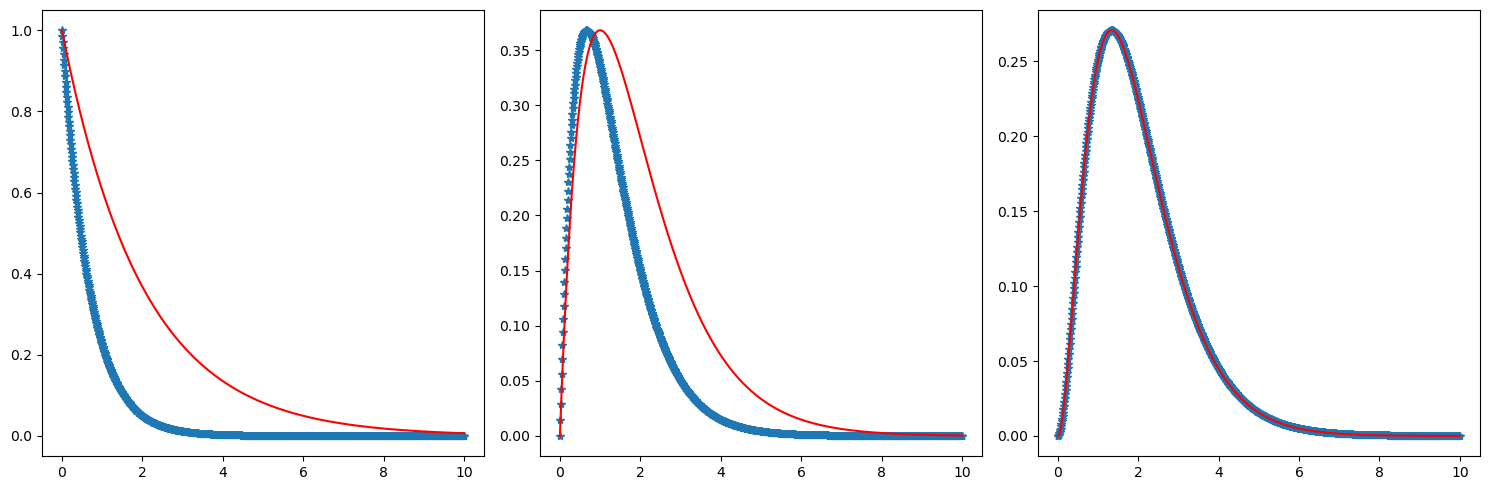

In [65]:
import matplotlib.pyplot as plt
import math

def cd_0(r, t, n = 3, tau = 2):
    """ 1 tank"""
    Cin = 0 # input concentration = 0
    return (n/tau)*(Cin - r[0])

def cd_1(r, t, n = 3, tau = 2):
    """ 2 tanks"""
    Cin = 0 # input concentration = 0
    rp = np.zeros(r.size)
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    return rp

def cd_2(r, t, n = 3, tau = 2):
    """ 3 tanks"""
    Cin = 0 # input concentration = 0
    rp = np.zeros(r.size)
    rp[0] = (n/tau)*(Cin - r[0])
    rp[1] = (n/tau)*(r[0] - r[1])
    rp[2] = (n/tau)*(r[1]- r[2])
    return rp

def c_0(t, tau = 2):
    return np.exp(-t / tau)

def c_1(t, tau = 2):
    return (2 * t / tau) * np.exp(-2 * t / tau)

def c_2(t, tau = 2):
    return 9* t**2 / (2 * tau**2) * np.exp(-3 * t / tau)

cake = ode_solver(cd_0, 0, 10, 1e-2, [1])
t, sol = cake.rk4()
cake1 = ode_solver(cd_1, 0, 10, 1e-2, [1, 0])
t1, sol1 = cake1.rk4()
cake2 = ode_solver(cd_2, 0, 10, 1e-2, [1, 0, 0])
t2, sol2 = cake2.rk4()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(t, sol, '*',label = "rk4")
plt.plot(t, c_0(t), '-',color = 'red', label = "analytical")

plt.subplot(1, 3, 2)
plt.plot(t1, sol1[: ,1], '*',label = "rk4")
plt.plot(t, c_1(t), '-', color = 'red', label = "analytical")

plt.subplot(1, 3, 3)
plt.plot(t2, sol2[:, 2], '*',label = "rk4")
plt.plot(t, c_2(t), '-', color = 'red', label = "analytical")

plt.tight_layout()
plt.show()

$$\textcolor{red}{\text{need to add adaptive stepping :(}}$$